---
title: "Maxwell–Stefan vs Fick for multicomponent mixtures"
description: "One physics, two bookkeepings: the Fick matrix [D] and the Maxwell–Stefan diffusivities describe the same mixture, and the page shows where the scalar effective diffusivity everyone actually uses falls apart."
categories: [sec:A, struct:S9, tier:T0, data:tier6, phase:gas]
date: 2026-07-31
---

# Maxwell–Stefan vs Fick for multicomponent mixtures

**Catalog ID:** `A4.2` · **Structure:** `S9` (implicit multicomponent flux) ·
**Tier:** T0

For a binary mixture there is one diffusion coefficient and everyone agrees
what it means. For three or more species there are three descriptions in
circulation, and they are not equally good:

1. the **Maxwell–Stefan** formulation — one drag coefficient
   $\mathrm{D}_{ij}$ per pair of species;
2. the **generalized Fick matrix** $[D]$ — $(n{-}1)^2$ coefficients with
   composition-dependent off-diagonal terms;
3. the **scalar effective diffusivity** $D_{i,\mathrm{eff}}$ — one number per
   species, which is what most reactor models quietly assume.

Krishna and Wesselingh's 1997 review is the standard argument that (1) and (2)
are *exactly the same physics* in different bookkeeping, while (3) is a
different, weaker claim that fails qualitatively as soon as the species
gradients couple. This page reproduces the review's two worked matrix examples
element by element, demonstrates the (1) ≡ (2) equivalence to machine precision
in a pymrm transport solve, and then shows against the Duncan–Toor measurements
exactly how (3) breaks: osmotic diffusion, reverse (uphill) diffusion and the
diffusion barrier.

## Background

The review opens with four experimental demonstrations that a single
composition-gradient-proportional flux law cannot describe multicomponent
mixtures: the Duncan–Toor two-bulb experiment, the Vinograd–McBain mixed-ion
cell, negative rejection in PEG/dextran ultrafiltration, and selectivity
reversal in a zeolite membrane. This page works the first one, because it is
an ideal gas at constant temperature and pressure — nothing exotic is present,
and Fick's scalar law still fails.

In that experiment (reproduced in full, against the measurements, on the
related page [`A4.9`](../A4.9-duncan-toor/index.ipynb)), nitrogen sits between
hydrogen and carbon dioxide, which exchange through a capillary. Reading the
nitrogen trajectory in time, Toor's (1957) three named anomalies appear in
sequence, and each corresponds to a statement about the *effective* Fick
diffusivity $D_2 = -J_2/(c_t \nabla x_2)$ of nitrogen:

| phenomenon | observation | required behaviour of $D_2$ |
|---|---|---|
| **osmotic diffusion** | flux without a gradient, $\nabla x_2 = 0,\ J_2 \neq 0$ | $D_2 \to \infty$ |
| **reverse (uphill) diffusion** | flux against the gradient | $D_2 < 0$ |
| **diffusion barrier** | no flux at the largest gradient, $J_2 = 0,\ \nabla x_2 \neq 0$ | $D_2 = 0$ |

A parameter that must pass through $\pm\infty$, negative values and zero
during one closed-cell experiment is not a transport property. The review's
resolution is that the *pair* Maxwell–Stefan diffusivities stay positive,
composition-independent and predictable, and all of the strangeness lives in
the transformation to Fick form. This page makes that statement quantitative.

**Scope.** The source is a 51-page review of the entire Maxwell–Stefan
research programme. This page reproduces its bulk-fluid core — the
$[B]$, $[\Gamma]$, $[D]$ formalism and its two worked examples, and the
breakdown of the effective-diffusivity simplification. Later sections of the
review (dusty gas, surface diffusion, electrolytes, membranes) belong to other
catalog entries (`A4.3`, `H1.9`, `J5.x`).

## The published model

**Maxwell–Stefan** (review eqs. 16–17). At constant $T$ and $p$, the driving
force on species $i$ is balanced by friction against every other species,
with one inverse drag coefficient $\mathrm{D}_{ij}$ per pair:

$$
-\frac{x_i}{RT}\nabla_{T,p}\,\mu_i
\;=\; \sum_{\substack{j=1\\ j\neq i}}^{n} \frac{x_j J_i - x_i J_j}{c_t\,\mathrm{D}_{ij}},
\qquad i = 1,\dots,n
$$

(the friction term is frame-invariant, so molar diffusion fluxes $J_i$ can be
used in place of the $N_i$ of the review's eq. 17). For an ideal gas the left
side is just $-\nabla x_i$ (eq. 36).

**Generalized Fick** (eqs. 24–28). Writing the driving force with the
$(n{-}1)\times(n{-}1)$ thermodynamic-factor matrix
$\Gamma_{ij} = \delta_{ij} + x_i\,\partial\ln\gamma_i/\partial x_j$ and
eliminating species $n$ puts the same equations in matrix form,

$$
(J) = -c_t\,[B]^{-1}[\Gamma]\,(\nabla x) \;=\; -c_t\,[D]\,(\nabla x),
\qquad [D] \equiv [B]^{-1}[\Gamma],
$$

with (eq. 26)

$$
B_{ii} = \frac{x_i}{\mathrm{D}_{in}} + \sum_{k\neq i}\frac{x_k}{\mathrm{D}_{ik}},
\qquad
B_{ij} = -x_i\!\left(\frac{1}{\mathrm{D}_{ij}} - \frac{1}{\mathrm{D}_{in}}\right)
\quad (j \neq i).
$$

Note what "eliminating species $n$" costs: the $n{-}1$ retained species get
explicit flux expressions and species $n$ is left to absorb the closure
$\sum_i J_i = 0$. Which species is eliminated is pure bookkeeping — $[B]$,
$[\Gamma]$ and $[D]$ all change with the choice, the fluxes do not. That
invariance is tested on this page, and it is where the scalar simplification
below parts company with Maxwell–Stefan.

**This is an identity, not an approximation** — the two formulations are the
same physics as long as $[D]$ keeps its full composition dependence. The
review's point is about *parametrisation*: the $\mathrm{D}_{ij}$ are
near-constant and predictable (for ideal gases, from kinetic theory; the
second law bounds them, $\mathrm{D}_{ij} \geq 0$, eq. 23), while the four
$D_{ij}$ elements swing with composition and $D_{12} \neq D_{21}$. In the
binary limit the transformation collapses to $D = \mathrm{D}\,\Gamma$
(eq. 13).

**The simplification that is *not* an identity** (eqs. 29–32). Dropping the
off-diagonal coupling gives one scalar per species,
$J_i = -c_t D_{i,\mathrm{eff}} \nabla x_i$. The review lists when that is
legitimate: all $\mathrm{D}_{ij}$ equal (eq. 29), or everything dilute in a
solvent (eq. 30), or species $i$ diffusing through *stagnant* others — the
condition behind Wilke's formula (eq. 32),

$$
D_{i,\mathrm{eff}} = \frac{1 - x_i}{\sum_{k \neq i} x_k / \mathrm{D}_{ik}} .
$$

The two-bulb experiment satisfies none of these (the pair diffusivities span a
factor of five and every species counter-diffuses), which is what this page
exploits.

The scalar law is a statement about *individual* species, so it too has to be
imposed on $n{-}1$ of them with the last one taking whatever the closure
leaves — and unlike the matrix form, **the answer now depends on that
choice**. The page measures the dependence.

| Symbol | Code | Meaning |
|---|---|---|
| $\mathrm{D}_{ij}$ | `d_ms` | Maxwell–Stefan pair diffusivity |
| $[B]$ | `build_b(...)` | inverted-drag matrix, eq. 26 |
| $[\Gamma]$ | `gamma_p` | thermodynamic-factor matrix, eq. 24 |
| $[D]$ | `fick_matrix(...)` | generalized Fick matrix, eq. 27 |
| eqs. 16–17 direct | `friction_solve(...)` | the $n$ friction balances solved as they stand, no $[B]$ |
| $D_{i,\mathrm{eff}}$ | `wilke_d(...)` | Wilke effective diffusivity, eq. 32 |
| $J_i$ | `flux_*(...)` | molar diffusion flux |
| $x_i$ | `x[:, i]` | mole fraction, capillary cell-centred |

## Parameters and assumptions

All numbers below were read off 600 dpi renders of the printed pages on
31 July 2026 — the PDF is an Acrobat Capture OCR of a scan and its text layer
cannot be trusted with signs or exponents.

**Worked example 1** (p. 872, "Ideal ternary gas mixtures revisited"):
H₂ (1)/N₂ (2)/CO₂ (3), $\mathrm{D}_{12} = 8.33$, $\mathrm{D}_{13} = 6.8$,
$\mathrm{D}_{23} = 1.68 \times 10^{-5}$ m² s⁻¹ ("from the kinetic gas
theory" — numerically identical to the values Duncan & Toor measured at
35.2 °C and 1 atm). $[B]$ and $[D]$ are printed at the equilibrium composition
$x = (0.25, 0.5, 0.25)$, together with a flux estimate for nitrogen.

**Worked example 2** (p. 871, "Non-ideal ternary mixtures"): acetone
(1)/benzene (2)/CCl₄ (3) at 25 °C and $x = (0.35, 0.35, 0.3)$, with printed
$[B]$, $[\Gamma]$ and $[D]$. One printed element is wrong — the sign of
$B_{12}$ — and the page proves it below from the paper's own numbers rather
than repairing it silently.

**Two-bulb demonstration**: geometry and conditions of the Duncan & Toor
cell, taken from the published `A4.9` page where each value was verified
against the original 1962 paper: bulbs 77.99 and 78.63 cm³, capillary 8.59 cm,
35.2 °C, 1 atm, effective $L/A = 258.1$ cm⁻¹. Initial compositions are the
$t=0$ points of the digitised dataset. Note a bookkeeping trap: the review's
eq. (3) numbers **swap the bulb labels** relative to Duncan & Toor's Fig. 2 —
in the review bulb 1 holds N₂ + CO₂, in the original (and on `A4.9`) bulb 1
is the H₂ + N₂ charge. This page follows the original's labelling.

**Assumptions** (all the review's): ideal gas, so $[\Gamma] = [I]$ for the
transport solve; isothermal, isobaric; closed cell, so $\sum_i N_i = 0$
(equimolar exchange) and $J_i = N_i$; capillary quasi-steady (volume ratio
~0.4%); bulbs well mixed; no viscous flow, no thermal diffusion.

In [1]:
# Colab environment cell — no-op if pymrm is already installed
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

# Make shared/gallery_utils.py importable locally and on Colab
if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/pymrm-gallery/"
               "main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from pymrm import construct_grad, construct_div, NumJac, newton
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "A4.2-maxwell-stefan-vs-fick"
PAGE_A49 = "A4.9-duncan-toor"          # cross-page dataset source
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [3]:
# --- Conditions and cell geometry --------------------------------------------
# Geometry/conditions of the Duncan & Toor cell, from the published A4.9 page
# (verified there against the 1962 paper).
T      = 308.35        # K       35.2 C water bath
p      = 101.325e3     # Pa      1 atm
R_GAS  = 8.314462      # J/(mol K)
c_t    = p / (R_GAS * T)          # mol/m3

length = 85.9e-3       # m       capillary length, 8.59 cm
# BULB LABELLING. Everything with a bulb NUMBER on this page follows Duncan &
# Toor (bulb 1 = the H2 + N2 charge), which is also the labelling of the A4.9
# dataset plotted below. The review's eq. (3) numbers the bulbs the other way
# round; the one cell that uses them names its variables by CHARGE
# (x_h2n2 / x_n2co2) instead of by number, and no volume enters that cell.
vol_1  = 77.99e-6      # m3      bulb 1 = H2 + N2 charge  (Duncan & Toor)
vol_2  = 78.63e-6      # m3      bulb 2 = N2 + CO2 charge (Duncan & Toor)
LA_EFF = 258.1e2       # 1/m     effective L/A measured from seven binary runs
area   = length / LA_EFF          # m2, effective

# --- Species: 0 = H2, 1 = N2, 2 = CO2 (the review's 1, 2, 3) ----------------
SPECIES = ["H$_2$", "N$_2$", "CO$_2$"]
n_c, n_i = 3, 2                   # species, independent mole fractions

# Maxwell-Stefan pair diffusivities as printed in the review (p. 872), m2/s.
# Identical to Duncan & Toor's measured 0.833 / 0.680 / 0.168 cm2/s.
d_ms = np.zeros((3, 3))
d_ms[0, 1] = d_ms[1, 0] = 8.33e-5      # H2 - N2
d_ms[0, 2] = d_ms[2, 0] = 6.8e-5       # H2 - CO2
d_ms[1, 2] = d_ms[2, 1] = 1.68e-5      # N2 - CO2

t_end = 16 * 3600.0    # s, the span of Duncan & Toor's Fig. 2
n_z   = 40             # capillary cells

print(f"c_t = {c_t:.2f} mol/m3;  pair diffusivities span a factor "
      f"{d_ms[0,1]/d_ms[1,2]:.1f}")

c_t = 39.52 mol/m3;  pair diffusivities span a factor 5.0


## The data

Two datasets, of different kinds, and the page keeps them apart:

1. **The review's own printed numbers** (tier 6 — the authors' computations,
   not measurements): the matrices $[B]$, $[\Gamma]$, $[D]$ of the two worked
   examples plus the eq. (3) compositions, transcribed from 600 dpi renders
   into `krishna-wesselingh-1997-worked-examples.csv`. One value is stored *as
   printed* although it is provably a typo (the sign of $B_{12}$ in the
   non-ideal example — settled below).
2. **The Duncan–Toor measurements** (tier 4 — experimental): the digitised,
   maintainer-reviewed bulb-composition dataset published with page `A4.9`,
   loaded cross-page. Its provenance, extraction method and error estimate
   live in that page's sidecar; nothing was re-digitised for this page.

In [4]:
wx = load_data("krishna-wesselingh-1997-worked-examples.csv", page=PAGE)
wx_meta = load_meta("krishna-wesselingh-1997-worked-examples.csv", page=PAGE)
V = {(r.example, r.symbol): r.value for r in wx.itertuples()}   # value lookup

exp = load_data("duncan-toor-1962-run1.csv", page=PAGE_A49)
exp_meta = load_meta("duncan-toor-1962-run1.csv", page=PAGE_A49)

print("page dataset :", cite_data(wx_meta))
print("cross-page   :", cite_data(exp_meta))
print(f"\n{len(wx)} transcribed values; {len(exp)} experimental points "
      f"(error {exp_meta['acquisition']['estimated_error'].strip().splitlines()[0]}...)")

page dataset : Krishna, R.; Wesselingh, J. A. (1997) — Chemical Engineering Science 52(6) 861-911 — doi:10.1016/S0009-2509(96)00458-7 — table
cross-page   : Duncan, J. B.; Toor, H. L. (1962) — AIChE Journal 8(1) 38-41 — doi:10.1002/aic.690080112 — digitised from Figure 2 — Variation of composition with time

41 transcribed values; 28 experimental points (error +/- 0.005 mole fraction, dominated by marker centroid placement against the 0.025 (upper block) and 0.05 (lower block) gridline spacing....)


## PyMRM implementation

The transport model is the two-bulb quasi-steady capillary of the `A4.9` page
— same grid, same operators, same Newton march — with the **flux closure made
swappable**. Four closures share one skeleton:

- **`flux_ms`** — Maxwell–Stefan: build $[B]$ at every capillary face from the
  local composition and solve the $2\times2$ system
  $(J) = -c_t [B]^{-1}(\nabla x)$ (structure `S9`: the flux is implicit).
- **`flux_fick`** — generalized Fick: the *explicit closed-form* elements of
  $[D](x) = [B]^{-1}$ (ideal gas, $[\Gamma]=[I]$), then
  $(J) = -c_t[D](\nabla x)$.
- **`flux_ms_friction`** — the same physics from the other end: the $n$
  friction balances of eqs. (16)–(17) assembled **as they stand**, closed by
  the cell constraint $\sum_k J_k = 0$, and solved for all $n$ fluxes at once.
  No species is eliminated, no $[B]$ is ever formed, no code is shared with
  `build_b`.
- **`flux_wilke`** — scalar effective diffusivity, eq. (32), evaluated at the
  local composition. Diagonal by construction: species $i$ responds to
  $\nabla x_i$ only.

**On what each comparison can and cannot show.** `flux_ms` and `flux_fick`
call the *same* `build_b`; one applies `np.linalg.solve` to the $2\times2$
matrix and the other its adjugate over its determinant. They must agree, and
a mistake inside `build_b` — a wrong `d_ms` index, a dropped minus on an
off-diagonal — would propagate identically into both. That comparison
therefore confirms the closed-form inverse and nothing more, and the page
labels it as the algebraic identity it is. **`flux_ms_friction` is the check
with power**: it shares no line of code with `build_b`, so it does test
eq. (26), the elimination of species $n$, and the transformation to
$[D] = [B]^{-1}$.

pymrm specifics: operators are assembled **once** — the bulb compositions
enter through the `shapes_d` boundary matrices, so the matrices never change
during the march. `construct_div` uses `nu=0` (Cartesian: a straight uniform
capillary). The `NumJac` stencil is `axes_diagonals=[0]` (each cell's residual
depends on its neighbours through the face fluxes) plus `axes_blocks=[-1]`
(all species couple pointwise through $[B]$); there is no second spatial axis,
so a `[-2,-1]` block is not needed.

In [5]:
shape = (n_z, n_i)
z_f = np.linspace(0.0, length, n_z + 1)
z_c = 0.5 * (z_f[:-1] + z_f[1:])

# Outward-normal bc, a*dx/dn + b*x = d. Dirichlet at both ends (b=1, a=0):
# x = xb1 at z=0 and x = xb2 at z=L. d=1 with shapes_d makes the boundary
# value an external unknown times a CONSTANT matrix.
bc = ({"a": 0.0, "b": 1.0, "d": 1.0},          # z = 0 -> bulb 1 composition
      {"a": 0.0, "b": 1.0, "d": 1.0})          # z = L -> bulb 2 composition

grad_mat, grad_bc_1, grad_bc_2 = construct_grad(
    shape, z_f, z_c, bc, axis=0, shapes_d=((1, n_i), (1, n_i)))
div_mat = construct_div(shape, z_f, nu=0, axis=0)      # nu=0: Cartesian
numjac = NumJac(shape, axes_diagonals=[0], axes_blocks=[-1])

In [6]:
def full_x(x_ind):
    """Append the dependent mole fraction: x_n = 1 - sum(x_1..x_{n-1})."""
    return np.concatenate([x_ind, 1.0 - x_ind.sum(axis=-1, keepdims=True)], axis=-1)


def build_b(x_ind, dms=d_ms):
    """[B] of review eq. (26), shape (..., 2, 2). Units s/m2.

    Species n_c-1 is the one eliminated; `dms` is passed explicitly so the
    same code can be run with the species reordered (see the permutation
    table below).
    """
    x = full_x(x_ind)
    b = np.zeros(x_ind.shape[:-1] + (n_i, n_i))
    for i in range(n_i):
        acc = x[..., i] / dms[i, n_c - 1]
        for k in range(n_c):
            if k != i:
                acc = acc + x[..., k] / dms[i, k]
        b[..., i, i] = acc
        for j in range(n_i):
            if j != i:
                b[..., i, j] = -x[..., i] * (1.0 / dms[i, j] - 1.0 / dms[i, n_c - 1])
    return b


def fick_matrix(x_ind, dms=d_ms):
    """[D](x) = [B]^-1 for the ideal gas, as EXPLICIT closed-form elements.

    Writing the four composition-dependent Fick coefficients out (adjugate over
    determinant) is the point: this is the 'generalized Fick' description as a
    modeller would code it, with no linear solve anywhere.
    """
    b = build_b(x_ind, dms)
    det = b[..., 0, 0] * b[..., 1, 1] - b[..., 0, 1] * b[..., 1, 0]
    d = np.empty_like(b)
    d[..., 0, 0] =  b[..., 1, 1] / det
    d[..., 0, 1] = -b[..., 0, 1] / det
    d[..., 1, 0] = -b[..., 1, 0] / det
    d[..., 1, 1] =  b[..., 0, 0] / det
    return d


def friction_solve(x_full, grad_ind, dms=d_ms):
    """The INDEPENDENT route: eqs. (16)-(17) solved as they stand.

    Assembles the n friction balances -grad(x_i) = sum_j (x_j J_i - x_i J_j)
    / (c_t D_ij) directly, replaces the last (linearly dependent) one by the
    closed-cell constraint sum_k J_k = 0, and returns all n fluxes. Nothing is
    eliminated, [B] is never formed and `build_b` is never called - so this
    path can disagree with `flux_ms`/`flux_fick` if eq. (26) or the [B]^-1
    transformation is coded wrongly.
    """
    n_f = x_full.shape[0]
    a = np.zeros((n_f, n_c, n_c))
    for i in range(n_c - 1):
        for j in range(n_c):
            if j != i:
                a[:, i, i] += x_full[:, j] / dms[i, j]
                a[:, i, j] -= x_full[:, i] / dms[i, j]
    a[:, n_c - 1, :] = 1.0                        # bootstrap: sum_k J_k = 0
    rhs = np.zeros((n_f, n_c))
    rhs[:, :n_c - 1] = -c_t * grad_ind            # the n-1 independent forces
    return np.linalg.solve(a, rhs[..., None])[..., 0]


def friction_residual(x_full, grad_ind, j_full, dms=d_ms):
    """Residual of the friction balance that `friction_solve` did NOT use.

    It must be satisfied automatically, because sum_i grad(x_i) = 0 makes the
    n balances linearly dependent. Scaled by the largest driving force.
    """
    i = n_c - 1
    g_i = -grad_ind.sum(axis=-1)
    lhs = sum((x_full[:, j] * j_full[:, i] - x_full[:, i] * j_full[:, j])
              / (c_t * dms[i, j]) for j in range(n_c) if j != i)
    return np.abs(lhs + g_i).max() / np.abs(grad_ind).max()


def fick_matrix_from_friction(x_ind, dms=d_ms):
    """[D] recovered column by column from `friction_solve`: apply a unit
    gradient in one independent species (species n taking -1 by closure) and
    read the fluxes. Never touches build_b."""
    x_full = full_x(x_ind).reshape(-1, n_c)
    cols = []
    for j in range(n_i):
        g = np.zeros((x_full.shape[0], n_i))
        g[:, j] = 1.0
        cols.append(-friction_solve(x_full, g, dms)[:, :n_i] / c_t)
    return np.stack(cols, axis=-1).reshape(x_ind.shape[:-1] + (n_i, n_i))


def wilke_d(x_ind, dms=d_ms, which=None):
    """Wilke effective diffusivity, review eq. (32).

    `which` selects the species; the default is the n-1 species the scalar law
    is imposed on, i.e. all but the eliminated one."""
    x = full_x(x_ind)
    which = range(n_i) if which is None else which
    return np.stack([(1.0 - x[..., i]) /
                     sum(x[..., k] / dms[i, k] for k in range(n_c) if k != i)
                     for i in which], axis=-1)


def grad_of(x, xb1, xb2):
    """Mole-fraction gradients at all faces (constant operators + bc terms)."""
    return (grad_mat @ x.reshape((-1, 1))
            + grad_bc_1 @ xb1[:n_i].reshape((-1, 1))
            + grad_bc_2 @ xb2[:n_i].reshape((-1, 1))).reshape(n_z + 1, n_i)


def face_of(x, xb1, xb2):
    xf = np.empty((n_z + 1, n_i))
    xf[1:-1] = 0.5 * (x[:-1] + x[1:])
    xf[0], xf[-1] = xb1[:n_i], xb2[:n_i]
    return xf


def flux_ms(x, xb1, xb2, dms=d_ms):
    """Maxwell-Stefan: solve [B] J = -c_t grad(x) at every face."""
    g, xf = grad_of(x, xb1, xb2), face_of(x, xb1, xb2)
    return -c_t * np.linalg.solve(build_b(xf, dms), g[..., None])[..., 0]


def flux_fick(x, xb1, xb2, dms=d_ms):
    """Generalized Fick: J = -c_t [D](x) grad(x), [D] explicit."""
    g, xf = grad_of(x, xb1, xb2), face_of(x, xb1, xb2)
    return -c_t * np.einsum('fij,fj->fi', fick_matrix(xf, dms), g)


def flux_ms_friction(x, xb1, xb2, dms=d_ms):
    """Maxwell-Stefan from the full friction system - no [B], nothing eliminated."""
    g, xf = grad_of(x, xb1, xb2), face_of(x, xb1, xb2)
    return friction_solve(full_x(xf), g, dms)[:, :n_i]


def flux_wilke(x, xb1, xb2, dms=d_ms):
    """Scalar effective diffusivity: J_i = -c_t D_i^W(x) grad(x_i)."""
    g, xf = grad_of(x, xb1, xb2), face_of(x, xb1, xb2)
    return -c_t * wilke_d(xf, dms) * g

In [7]:
def solve_capillary(flux, x_init, xb1, xb2):
    """Quasi-steady capillary: div(J_i) = 0 with bulb-composition Dirichlet bc."""
    def residual(x):
        g, jac = numjac(
            lambda xx: (div_mat @ flux(xx, xb1, xb2).reshape((-1, 1))).reshape(shape), x)
        return g.reshape((-1, 1)), jac
    result = newton(residual, x_init, maxfev=30, tol=1e-12)
    return result.x.reshape(shape), result.success


def simulate(flux, x1_init, x2_init, n_steps=400, t_end=t_end):
    """Backward-Euler march of the bulbs; capillary quasi-steady. Deterministic:
    fixed grid, fixed steps, fixed Newton tolerance, no warm-start continuation
    across parameter sweeps."""
    dt = t_end / n_steps
    xb1, xb2 = x1_init.copy(), x2_init.copy()
    x = np.linspace(0, 1, n_z)[:, None] * (xb2[:n_i] - xb1[:n_i]) + xb1[:n_i]
    t_h, h1, h2, hJ = [0.0], [xb1.copy()], [xb2.copy()], []
    converged = True

    for _ in range(n_steps):
        xb1n, xb2n = xb1.copy(), xb2.copy()
        for _ in range(3):                     # inner iterations on the coupling
            x, ok = solve_capillary(flux, x, xb1n, xb2n)
            converged &= ok
            j_face = flux(x, xb1n, xb2n)
            xb1n[:n_i] = xb1[:n_i] - area * j_face[0] / (vol_1 * c_t) * dt
            xb2n[:n_i] = xb2[:n_i] + area * j_face[-1] / (vol_2 * c_t) * dt
            xb1n[n_i] = 1.0 - xb1n[:n_i].sum()
            xb2n[n_i] = 1.0 - xb2n[:n_i].sum()
        xb1, xb2 = xb1n, xb2n
        t_h.append(t_h[-1] + dt); h1.append(xb1.copy()); h2.append(xb2.copy())
        hJ.append(j_face.mean(axis=0))
    hJ.append(hJ[-1])
    return (np.asarray(t_h) / 3600.0, np.asarray(h1), np.asarray(h2),
            np.asarray(hJ), converged)

## Results

### The worked matrix examples, element by element

**Example 1 — ideal gas.** The review evaluates eq. (26) and $[D]=[B]^{-1}$
for H₂/N₂/CO₂ at the equilibrium composition and prints both matrices. The
same `build_b`/`fick_matrix` functions that will drive the transport solve
below must reproduce them — so this check validates the *implementation*, not
just the transcription. (The printed matrices are rounded to 2–3 significant
figures; the review computed $[D]$ from its unrounded $[B]$, so a few tenths
of a percent to ~1% is the attainable agreement, and 3.5% on the heavily
rounded $0.007\times10^5$ element.)

In [8]:
x_eq = np.array([V["ideal", "x1"], V["ideal", "x2"]])
b_calc = build_b(x_eq[None, :])[0]
d_calc = fick_matrix(x_eq[None, :])[0]

b_print = np.array([[V["ideal", "B11"], V["ideal", "B12"]],
                    [V["ideal", "B21"], V["ideal", "B22"]]])
d_print = np.array([[V["ideal", "DF11"], V["ideal", "DF12"]],
                    [V["ideal", "DF21"], V["ideal", "DF22"]]])

dev_b = np.abs(b_calc - b_print) / np.abs(b_print)
dev_d = np.abs(d_calc - d_print) / np.abs(d_print)

print("[B] (1e5 s/m2)      printed      recomputed    rel.dev")
print("[D] (1e-5 m2/s)")
for nm, Mp, Mc, dv, s in [("B", b_print, b_calc, dev_b, 1e5),
                          ("D", d_print, d_calc, dev_d, 1e-5)]:
    for i in range(2):
        for j in range(2):
            print(f"  {nm}{i+1}{j+1}   {Mp[i,j]/s:12.4f} {Mc[i,j]/s:12.4f}"
                  f"   {dv[i,j]:8.2%}")

ex1_d_maxdev = float(dev_d.max())
print(f"\nmax relative deviation of the recomputed [D]: {ex1_d_maxdev:.2%}")
print(f"note the sign structure the review argues from: D21 = "
      f"{d_calc[1,0]*1e5:+.2f}e-5 is LARGER in magnitude than D22 = "
      f"{d_calc[1,1]*1e5:+.2f}e-5 - nitrogen answers hydrogen's gradient "
      f"more strongly than its own.")

[B] (1e5 s/m2)      printed      recomputed    rel.dev
[D] (1e-5 m2/s)
  B11         0.1340       0.1336      0.33%
  B12         0.0070       0.0068      3.53%
  B21         0.2370       0.2376      0.25%
  B22         0.4760       0.4764      0.09%
  D11         7.6800       7.6813      0.02%
  D12        -0.1100      -0.1089      1.03%
  D21        -3.8320      -3.8306      0.04%
  D22         2.1600       2.1532      0.32%

max relative deviation of the recomputed [D]: 1.03%
note the sign structure the review argues from: D21 = -3.83e-5 is LARGER in magnitude than D22 = +2.15e-5 - nitrogen answers hydrogen's gradient more strongly than its own.


The review then estimates the initial nitrogen flux in its
highlighted run from these matrices:
$J_2 = -(c_t/\ell)\,(D_{21}\Delta x_1 + D_{22}\Delta x_2)$ with
$\Delta x_1 = -0.25$, $\Delta x_2 = 0$ (bulb minus equilibrium). With
$\Delta x_2 = 0$ exactly, a scalar Fick law of *any* diffusivity gives
$J_2 = 0$; the printed coefficients give a nitrogen flux **half the hydrogen
flux** — osmotic diffusion, from the cross-coefficient alone.

In [9]:
dx = np.array([V["ideal", "dx1"], V["ideal", "dx2"]])   # bulb - equilibrium
j_scaled_print = d_print @ dx        # J_i * (l/c_t), review's estimate, m2/s
j_scaled_calc = d_calc @ dx
print("review's J2*(l/c_t) from the printed matrix : "
      f"{abs(j_scaled_print[1])*1e5:.3f}e-5 m2/s  (printed arithmetic: "
      f"|-3.83 x -0.25| = 0.958e-5)")
print(f"same from the recomputed matrix             : {abs(j_scaled_calc[1])*1e5:.3f}e-5")
print(f"flux ratio J2/J1 at zero N2 driving force   : {j_scaled_print[1]/j_scaled_print[0]:+.3f}"
      f"  (recomputed {j_scaled_calc[1]/j_scaled_calc[0]:+.3f})")
ratio_print = float(j_scaled_print[1] / j_scaled_print[0])

review's J2*(l/c_t) from the printed matrix : 0.958e-5 m2/s  (printed arithmetic: |-3.83 x -0.25| = 0.958e-5)
same from the recomputed matrix             : 0.958e-5
flux ratio J2/J1 at zero N2 driving force   : -0.499  (recomputed -0.499)


**Example 2 — non-ideal liquid, and a typo settled from the
paper's own numbers.** For acetone/benzene/CCl₄ the review prints all three
matrices of $[D] = [B]^{-1}[\Gamma]$, which makes the triple self-checking.
The printed $B_{12} = -0.036\times10^9$ cannot be right, on four independent
grounds — the first of which never uses $B_{12}$ at all:

1. **Back-solve, $B_{12}$ never touched.** The *other three* printed elements
   of $[B]$ determine all three diffusivities uniquely. Writing
   $a = 1/\mathrm{D}_{12}$, $b = 1/\mathrm{D}_{13}$, $c = 1/\mathrm{D}_{23}$,
   eq. (26) gives $B_{21} = -x_2(a-c)$, $B_{22} = x_1 a + (x_2+x_3)c$ and
   $B_{11} = x_2 a + (x_1+x_3) b$, so
   $$a = B_{22} - \frac{x_2+x_3}{x_2}B_{21},\qquad
     c = a + \frac{B_{21}}{x_2},\qquad
     b = \frac{B_{11} - x_2 a}{x_1 + x_3}.$$
   The printed $B_{11}, B_{21}, B_{22}$ return the authors' *unrounded*
   diffusivities, 3.375 / 2.507 / 1.661 $\times10^{-9}$ m² s⁻¹ against the
   printed 3.4 / 2.5 / 1.7. Feeding those back into eq. (26) predicts
   $B_{12} = +0.0359\times10^9$ — the printed **magnitude** 0.036 to within
   0.2%, with the opposite **sign**. Nothing in this route depends on any
   assumption about $B_{12}$, or on the closure test of point 4.
2. eq. (26) with the printed (rounded) diffusivities gives
   $B_{12} = -x_1(1/\mathrm{D}_{12} - 1/\mathrm{D}_{13}) = +0.037\times10^9$,
   necessarily positive because $\mathrm{D}_{12} > \mathrm{D}_{13}$.
3. **The review's other worked example disagrees with this one.** The ideal
   gas example on p. 872 has the same ordering $\mathrm{D}_{12} >
   \mathrm{D}_{13}$ and prints $B_{12} = +0.007\times10^5$ — positive. Under
   any single sign convention for eq. (26) the two printed examples are
   mutually inconsistent, so one of them is a typo; and the ideal one is the
   one this page reproduces element by element (above).
4. $[B]^{-1}[\Gamma]$ reproduces the printed $[D]$ to ≤1.7% per element with
   the $+$ sign, and puts $D_{12}$ out by 75% with the printed $-$ sign. The
   rival hypothesis — that $B_{21}$ carries the typo instead — is tested below
   and misses the printed $[D]$ by 302%.

Nothing here involves anything outside the paper. The CSV stores the value as
printed; the transformation below uses the corrected sign.

In [10]:
# Non-ideal example: acetone (1) / benzene (2) / CCl4 (3) at 25 C.
d_ms_liq = np.zeros((3, 3))
d_ms_liq[0, 1] = d_ms_liq[1, 0] = V["nonideal", "D12"]
d_ms_liq[0, 2] = d_ms_liq[2, 0] = V["nonideal", "D13"]
d_ms_liq[1, 2] = d_ms_liq[2, 1] = V["nonideal", "D23"]
x_liq = np.array([V["nonideal", "x1"], V["nonideal", "x2"], V["nonideal", "x3"]])

# eq. (26) recomputation (independent of the printed [B]):
b_liq = np.zeros((2, 2))
for i in range(2):
    b_liq[i, i] = x_liq[i] / d_ms_liq[i, 2] + sum(
        x_liq[k] / d_ms_liq[i, k] for k in range(3) if k != i)
    for j in range(2):
        if j != i:
            b_liq[i, j] = -x_liq[i] * (1 / d_ms_liq[i, j] - 1 / d_ms_liq[i, 2])

b_liq_print = np.array([[V["nonideal", "B11"], V["nonideal", "B12"]],
                        [V["nonideal", "B21"], V["nonideal", "B22"]]])
gamma_p = np.array([[V["nonideal", "G11"], V["nonideal", "G12"]],
                    [V["nonideal", "G21"], V["nonideal", "G22"]]])
d_liq_print = np.array([[V["nonideal", "DF11"], V["nonideal", "DF12"]],
                        [V["nonideal", "DF21"], V["nonideal", "DF22"]]])

print("route 1 - back-solve the diffusivities from B11, B21, B22 ONLY "
      "(B12 unused):")
a_inv = b_liq_print[1, 1] - (x_liq[1] + x_liq[2]) * b_liq_print[1, 0] / x_liq[1]
c_inv = a_inv + b_liq_print[1, 0] / x_liq[1]
b_inv = (b_liq_print[0, 0] - x_liq[1] * a_inv) / (x_liq[0] + x_liq[2])
d_back = np.array([1 / a_inv, 1 / b_inv, 1 / c_inv])       # D12, D13, D23
b12_pred = -x_liq[0] * (a_inv - b_inv)
print(f"   D12, D13, D23 back-solved : {d_back[0]*1e9:.3f}, {d_back[1]*1e9:.3f}, "
      f"{d_back[2]*1e9:.3f} e-9 m2/s   (printed {d_ms_liq[0,1]*1e9:.1f}, "
      f"{d_ms_liq[0,2]*1e9:.1f}, {d_ms_liq[1,2]*1e9:.1f})")
b12_magdev = abs(abs(b12_pred) - abs(b_liq_print[0, 1])) / abs(b_liq_print[0, 1])
print(f"   eq. (26) then predicts B12 = {b12_pred/1e9:+.4f}e9 vs printed "
      f"{b_liq_print[0,1]/1e9:+.3f}e9 -> magnitude to {b12_magdev:.1%}, sign opposite")
print(f"route 2 - eq. (26) with the printed diffusivities: B12 = "
      f"{b_liq[0,1]/1e9:+.3f}e9   (positive because D12 > D13)")
print(f"route 3 - the ideal example (p. 872), same D12 > D13 ordering, prints "
      f"B12 = {V['ideal','B12']/1e5:+.3f}e5 - positive\n")

b_signfix = b_liq_print.copy(); b_signfix[0, 1] = abs(b_signfix[0, 1])
b_rival = b_liq_print.copy(); b_rival[1, 0] = -b_rival[1, 0]   # 'B21 is the typo'
b_both = b_liq_print.copy(); b_both[0, 1] = abs(b_both[0, 1]); b_both[1, 0] *= -1
print("route 4 - which hypothesis reproduces the printed [D]?")
for label, B in [("as printed, B12 = -0.036e9   ", b_liq_print),
                 ("B12 = +0.036e9 (this page)   ", b_signfix),
                 ("[B] recomputed from eq. (26) ", b_liq),
                 ("rival: B21 = -0.107e9 instead", b_rival),
                 ("both off-diagonals negated   ", b_both)]:
    d_from = np.linalg.solve(B, gamma_p)
    dev = np.abs(d_from - d_liq_print) / np.abs(d_liq_print)
    print(f"   {label}: [B]^-1[Gamma] vs printed [D], max dev {dev.max():8.2%}")
ex2_identity_maxdev = float((np.abs(np.linalg.solve(b_signfix, gamma_p) - d_liq_print)
                             / np.abs(d_liq_print)).max())
print(f"\nOnly the corrected sign closes the printed triple - to "
      f"{ex2_identity_maxdev:.2%} per element, i.e. [D] = [B]^-1 [Gamma] holds")
print("between the paper's own printed matrices. The residual is print rounding:")
print("the matrices carry two significant figures, and the back-solved "
      "diffusivities above show the authors used unrounded ones.")

route 1 - back-solve the diffusivities from B11, B21, B22 ONLY (B12 unused):
   D12, D13, D23 back-solved : 3.375, 2.507, 1.661 e-9 m2/s   (printed 3.4, 2.5, 1.7)
   eq. (26) then predicts B12 = +0.0359e9 vs printed -0.036e9 -> magnitude to 0.2%, sign opposite
route 2 - eq. (26) with the printed diffusivities: B12 = +0.037e9   (positive because D12 > D13)
route 3 - the ideal example (p. 872), same D12 > D13 ordering, prints B12 = +0.007e5 - positive

route 4 - which hypothesis reproduces the printed [D]?
   as printed, B12 = -0.036e9   : [B]^-1[Gamma] vs printed [D], max dev   75.06%
   B12 = +0.036e9 (this page)   : [B]^-1[Gamma] vs printed [D], max dev    1.65%
   [B] recomputed from eq. (26) : [B]^-1[Gamma] vs printed [D], max dev    5.44%
   rival: B21 = -0.107e9 instead: [B]^-1[Gamma] vs printed [D], max dev  301.57%
   both off-diagonals negated   : [B]^-1[Gamma] vs printed [D], max dev  293.11%

Only the corrected sign closes the printed triple - to 1.65% per element, i.e. [D] =

### The two-bulb experiment under three flux closures

Now the same pymrm skeleton is run four times — Maxwell–Stefan via $[B]$,
generalized Fick with the explicit composition-dependent $[D](x)$,
Maxwell–Stefan from the raw friction balances, and the Wilke scalar — from the
measured $t=0$ compositions. Lines that follow are model; markers are the
digitised measurements from `A4.9`. Nothing is fitted anywhere on this
page.

In [11]:
# Initial compositions: the t=0 points of the digitised dataset (bulb 1 = H2+N2).
t0 = exp[exp.time_h == 0]
x1_0 = np.array([float(t0[(t0.bulb == 1) & (t0.species == s)].x.iloc[0])
                 for s in ["H2", "N2", "CO2"]])
x2_0 = np.array([float(t0[(t0.bulb == 2) & (t0.species == s)].x.iloc[0])
                 for s in ["H2", "N2", "CO2"]])
x1_0, x2_0 = x1_0 / x1_0.sum(), x2_0 / x2_0.sum()

runs = {}
for name, fl in [("Maxwell-Stefan", flux_ms),
                 ("generalized Fick [D](x)", flux_fick),
                 ("MS, friction form", flux_ms_friction),
                 ("Wilke effective D", flux_wilke)]:
    runs[name] = simulate(fl, x1_0, x2_0)
    print(f"{name:<26} converged: {runs[name][4]}")

t_h = runs["Maxwell-Stefan"][0]


def traj_diff(a, b):
    """Largest mole-fraction difference between two runs, both bulbs."""
    return float(max(np.abs(runs[a][1] - runs[b][1]).max(),
                     np.abs(runs[a][2] - runs[b][2]).max()))


ms_fick_equiv = traj_diff("Maxwell-Stefan", "generalized Fick [D](x)")
ms_indep_equiv = traj_diff("Maxwell-Stefan", "MS, friction form")
print(f"\nMS via [B] vs generalized Fick [D](x) = [B]^-1 : {ms_fick_equiv:.2e}")
print("   ALGEBRAIC IDENTITY. Both call the same build_b; this confirms the")
print("   closed-form 2x2 inverse, and cannot detect an error inside [B].")
print(f"MS via [B] vs the raw friction system         : {ms_indep_equiv:.2e}")
print("   INDEPENDENT IMPLEMENTATION. No shared code, no [B], no species")
print("   eliminated - this is what tests eq. (26) and eq. (27).")

Maxwell-Stefan             converged: True


generalized Fick [D](x)    converged: True


MS, friction form          converged: True


Wilke effective D          converged: True

MS via [B] vs generalized Fick [D](x) = [B]^-1 : 8.88e-16
   ALGEBRAIC IDENTITY. Both call the same build_b; this confirms the
   closed-form 2x2 inverse, and cannot detect an error inside [B].
MS via [B] vs the raw friction system         : 7.77e-16
   INDEPENDENT IMPLEMENTATION. No shared code, no [B], no species
   eliminated - this is what tests eq. (26) and eq. (27).


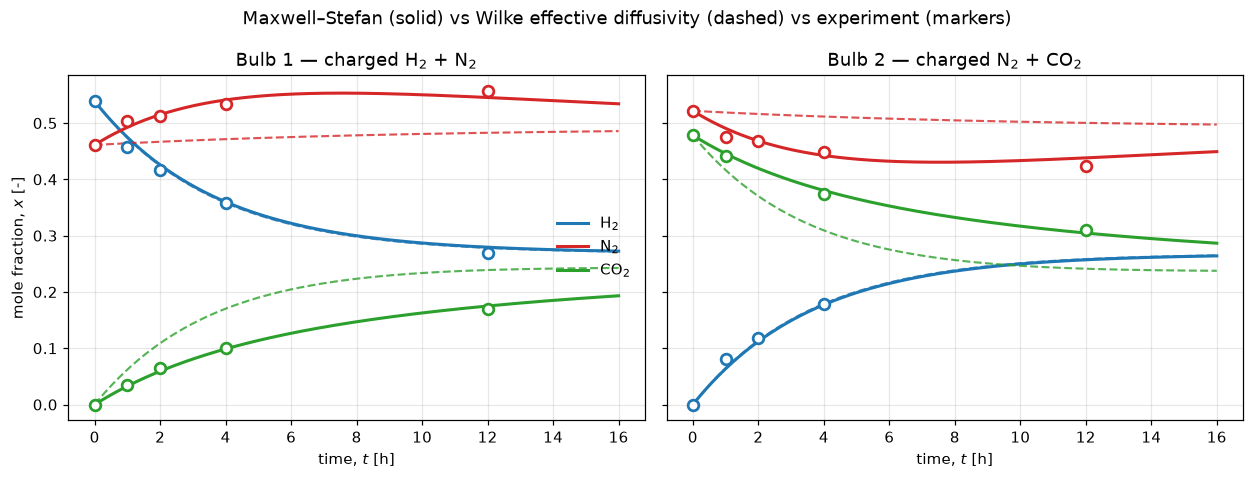

In [12]:
COL = {"H2": "tab:blue", "N2": "tab:red", "CO2": "tab:green"}
KEY = ["H2", "N2", "CO2"]
_, x1_ms, x2_ms, J_ms, _ = runs["Maxwell-Stefan"]
_, x1_wk, x2_wk, _, _ = runs["Wilke effective D"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for ax, (ms, wk), b in zip(axes, [(x1_ms, x1_wk), (x2_ms, x2_wk)], (1, 2)):
    for i, sp in enumerate(KEY):
        ax.plot(t_h, ms[:, i], color=COL[sp], lw=2, label=SPECIES[i])
        ax.plot(t_h, wk[:, i], "--", color=COL[sp], lw=1.4, alpha=0.8,
                label="_nolegend_")
        sub = exp[(exp.bulb == b) & (exp.species == sp)]
        ax.plot(sub.time_h, sub.x, "o", color=COL[sp], ms=7, mfc="white",
                mew=1.8, zorder=5, label="_nolegend_")
    ax.set_xlabel("time, $t$ [h]")
    ax.set_title(f"Bulb {b}" + (" — charged H$_2$ + N$_2$" if b == 1
                                else " — charged N$_2$ + CO$_2$"))
axes[0].set_ylabel("mole fraction, $x$ [-]")
axes[0].legend(frameon=False, loc="center right")
fig.suptitle("Maxwell–Stefan (solid) vs Wilke effective diffusivity (dashed) "
             "vs experiment (markers)")
fig.tight_layout()
plt.show()

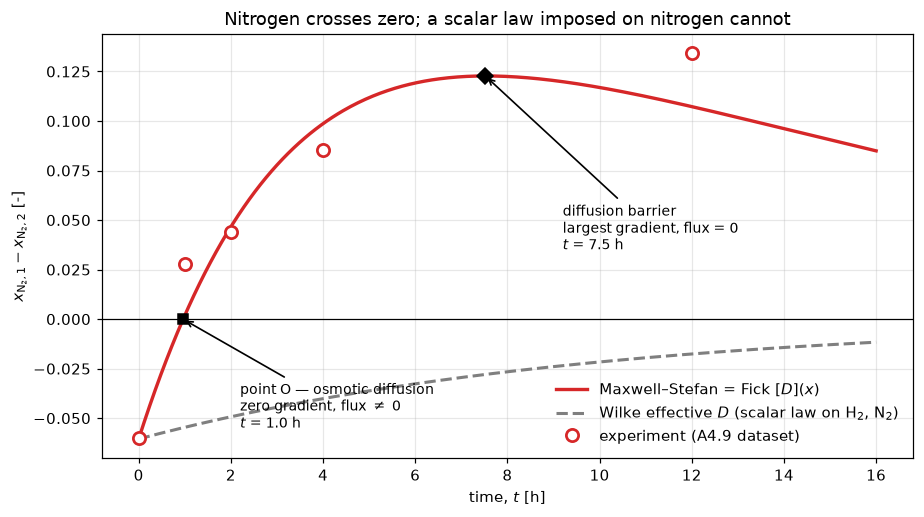

N2 difference: starts -0.0605, crosses zero at t = 0.96 h, peaks +0.1227 at t = 7.52 h
Wilke closure with the scalar law imposed on H2 and N2 (CO2 taking the closure):
   monotonic from -0.0605 to -0.0116 - no crossing, no barrier.
Structural reason: a positive scalar diffusivity moves species i strictly down
its OWN gradient, so the bulb difference of any species CARRYING the scalar law can
only decay towards zero. Which species carry it is a bookkeeping choice - next cell.


In [13]:
# The nitrogen signal: its difference between the bulbs.
dx_ms = x1_ms[:, 1] - x2_ms[:, 1]
dx_wk = x1_wk[:, 1] - x2_wk[:, 1]
exp_n2 = exp[exp.species == "N2"].pivot(index="time_h", columns="bulb",
                                        values="x").dropna()
dx_exp = (exp_n2[1] - exp_n2[2]).values

# Deterministic feature location on the fixed-step trajectory:
i_zero = int(np.argmin(np.abs(dx_ms[:len(dx_ms)//2])))     # point O (gradient = 0)
i_peak = int(np.argmax(np.abs(dx_ms)))                     # barrier (flux = 0)
t_zero, t_peak = t_h[i_zero], t_h[i_peak]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(t_h, dx_ms, color="tab:red", lw=2.2, label="Maxwell–Stefan = Fick $[D](x)$")
ax.plot(t_h, dx_wk, "--", color="tab:gray", lw=2,
        label="Wilke effective $D$ (scalar law on H$_2$, N$_2$)")
ax.plot(exp_n2.index, dx_exp, "o", color="tab:red", ms=8, mfc="white",
        mew=1.8, zorder=5, label="experiment (A4.9 dataset)")
ax.axhline(0.0, color="k", lw=0.8)
ax.plot(t_zero, 0.0, "s", color="k", ms=7, zorder=6)
ax.plot(t_peak, dx_ms[i_peak], "D", color="k", ms=7, zorder=6)
ax.annotate(f"point O — osmotic diffusion\nzero gradient, flux $\\neq$ 0\n"
            f"$t$ = {t_zero:.1f} h", xy=(t_zero, 0.0), xytext=(2.2, -0.055),
            arrowprops=dict(arrowstyle="->", lw=1.1), fontsize=9)
ax.annotate(f"diffusion barrier\nlargest gradient, flux = 0\n$t$ = {t_peak:.1f} h",
            xy=(t_peak, dx_ms[i_peak]), xytext=(9.2, 0.035),
            arrowprops=dict(arrowstyle="->", lw=1.1), fontsize=9)
ax.set_xlabel("time, $t$ [h]")
ax.set_ylabel(r"$x_{\mathrm{N_2},1} - x_{\mathrm{N_2},2}$ [-]")
ax.set_title("Nitrogen crosses zero; a scalar law imposed on nitrogen cannot")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

print(f"N2 difference: starts {dx_ms[0]:+.4f}, crosses zero at t = {t_zero:.2f} h, "
      f"peaks {dx_ms[i_peak]:+.4f} at t = {t_peak:.2f} h")
print(f"Wilke closure with the scalar law imposed on H2 and N2 (CO2 taking the "
      f"closure):\n   monotonic from {dx_wk[0]:+.4f} to {dx_wk[-1]:+.4f} - no "
      "crossing, no barrier.")
print("Structural reason: a positive scalar diffusivity moves species i strictly "
      "down\nits OWN gradient, so the bulb difference of any species CARRYING the "
      "scalar law can\nonly decay towards zero. Which species carry it is a "
      "bookkeeping choice - next cell.")

### Which species carries the scalar law — and why it matters

The dashed curve above is *the* Wilke curve only for one bookkeeping choice.
`n_i = 2` imposes eq. (32) on H₂ and N₂, and leaves CO₂ to absorb
$\sum_i J_i = 0$. Nothing physical picks that ordering, and the Reuse section
below invites you to change it — so the honest thing is to measure what it
costs.

Below, the whole calculation is repeated with each species in turn taking the
dependent role. Same grid, same time steps, same data, same $t=0$
compositions; only the labelling changes. Maxwell–Stefan should be exactly
invariant (the elimination is undone by the closure), and the scalar law
should not be.

In [14]:
idx = {"H2": 0, "N2": 1, "CO2": 2}
PERMS = {"CO2": (0, 1, 2), "H2": (1, 2, 0), "N2": (0, 2, 1)}   # last = eliminated


def dev_vs_exp(h1, h2, t=t_h):
    """|model - measured| at every digitised point, mole-fraction units."""
    d = [np.interp(r.time_h, t, (h1 if r.bulb == 1 else h2)[:, idx[r.species]]) - r.x
         for r in exp.itertuples()]
    return np.abs(np.asarray(d))


def n2_signal(h1, h2, t=t_h):
    """N2 bulb-difference trajectory, and its mean error against the data."""
    dxn = h1[:, 1] - h2[:, 1]
    return dxn, float(np.abs(np.interp(exp_n2.index, t, dxn) - dx_exp).mean())


def run_ordering(perm, flux):
    """Re-run the whole transient with perm[-1] as the eliminated species."""
    perm = np.asarray(perm)
    dms_p = d_ms[np.ix_(perm, perm)]                 # pair diffusivities reordered
    t, h1, h2, _, ok = simulate(lambda x, a, b: flux(x, a, b, dms_p),
                                x1_0[perm], x2_0[perm])
    p1, p2 = np.empty_like(h1), np.empty_like(h2)
    p1[:, perm], p2[:, perm] = h1, h2                # back to H2 / N2 / CO2 order
    return t, p1, p2, ok


perm_res = {}
for elim, perm in PERMS.items():
    for tag, fl in [("MS", flux_ms), ("Wilke", flux_wilke)]:
        t_p, p1, p2, ok = run_ordering(perm, fl)
        dxn, n2e = n2_signal(p1, p2, t_p)
        perm_res[(elim, tag)] = (float(dev_vs_exp(p1, p2, t_p).mean()), n2e,
                                 dxn, t_p, ok)


def _fmt(key):
    mean, n2e, dxn = perm_res[key][0] * 100, perm_res[key][1] * 100, perm_res[key][2]
    cross = "yes" if dxn.min() < 0 < dxn.max() else "no "
    return f"{mean:5.2f}  {n2e:6.2f}   {cross} {dxn.max():+.4f}"


print("deviations vs the A4.9 measurements, mole % (model - measured)\n")
print("eliminated |        Maxwell-Stefan          |         Wilke scalar")
print(" species   | mean   N2 diff  cross  peak    | mean   N2 diff  cross  peak")
print("-" * 74)
for elim in PERMS:
    star = " *" if elim == "CO2" else "  "
    print(f"  {elim:<4}{star}   | {_fmt((elim, 'MS'))}   | {_fmt((elim, 'Wilke'))}")
print("-" * 74)
print("* the ordering used everywhere else on this page")

ms_means = [perm_res[(e, "MS")][0] for e in PERMS]
ms_n2 = [perm_res[(e, "MS")][1] for e in PERMS]
wk_means = [perm_res[(e, "Wilke")][0] * 100 for e in PERMS]
wk_n2 = [perm_res[(e, "Wilke")][1] * 100 for e in PERMS]
ms_elim_spread = float(max(max(ms_means) - min(ms_means), max(ms_n2) - min(ms_n2)))
print(f"\nMaxwell-Stefan: the three orderings agree to {ms_elim_spread:.1e} in "
      "mole fraction - the\n   elimination is exact bookkeeping, as eq. (27) "
      "requires. Invariance is the claim,\n   and it is checked, not assumed.")
print(f"Wilke: mean deviation {min(wk_means):.2f} - {max(wk_means):.2f} mole %, "
      f"N2 signal {min(wk_n2):.2f} - {max(wk_n2):.2f} mole %, depending on nothing")
print("   but which species you chose to eliminate. And when N2 is the eliminated "
      "species\n   its flux is minus the sum of two scalar-law fluxes, so it CAN "
      "cross zero - the\n   'barrier' then costs nothing structurally, it is an "
      "artefact of the bookkeeping.")

deviations vs the A4.9 measurements, mole % (model - measured)

eliminated |        Maxwell-Stefan          |         Wilke scalar
 species   | mean   N2 diff  cross  peak    | mean   N2 diff  cross  peak
--------------------------------------------------------------------------
  CO2  *   |  0.59    1.38   yes +0.1227   |  3.14    9.07   no  -0.0116
  H2       |  0.59    1.38   yes +0.1227   |  4.31    9.03   no  -0.0112
  N2       |  0.59    1.38   yes +0.1227   |  1.44    3.39   yes +0.1935
--------------------------------------------------------------------------
* the ordering used everywhere else on this page

Maxwell-Stefan: the three orderings agree to 3.9e-16 in mole fraction - the
   elimination is exact bookkeeping, as eq. (27) requires. Invariance is the claim,
   and it is checked, not assumed.
Wilke: mean deviation 1.44 - 4.31 mole %, N2 signal 3.39 - 9.07 mole %, depending on nothing
   but which species you chose to eliminate. And when N2 is the eliminated species
   it

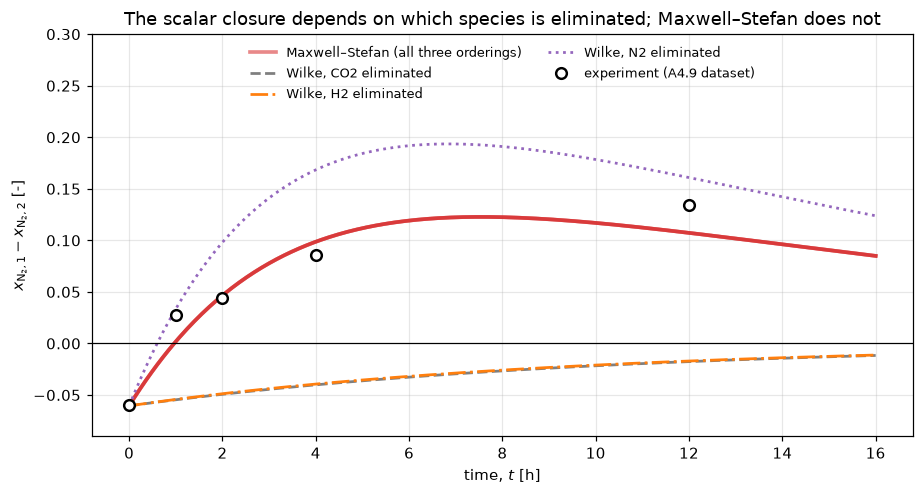

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
STY = {"CO2": ("tab:gray", "--"), "H2": ("tab:orange", "-."), "N2": ("tab:purple", ":")}
for elim in PERMS:
    t_p = perm_res[(elim, "MS")][3]
    ax.plot(t_p, perm_res[(elim, "MS")][2], color="tab:red", lw=2.4, alpha=0.55,
            label="Maxwell–Stefan (all three orderings)" if elim == "CO2" else None)
    col, ls = STY[elim]
    ax.plot(t_p, perm_res[(elim, "Wilke")][2], ls, color=col, lw=1.8,
            label=f"Wilke, {elim} eliminated")
ax.plot(exp_n2.index, dx_exp, "o", color="k", ms=7, mfc="white", mew=1.6,
        zorder=5, label="experiment (A4.9 dataset)")
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xlabel("time, $t$ [h]")
ax.set_ylabel(r"$x_{\mathrm{N_2},1} - x_{\mathrm{N_2},2}$ [-]")
ax.set_title("The scalar closure depends on which species is eliminated; "
             "Maxwell–Stefan does not")
ax.set_ylim(-0.09, 0.30)                       # headroom for the legend
ax.legend(frameon=False, fontsize=8.5, loc="upper center", ncol=2)
fig.tight_layout()
plt.show()

### What the 'effective diffusivity of nitrogen' would have to do

Back out $D_{2,\mathrm{eff}} = -J_2/(c_t\nabla x_2)$ from the Maxwell–Stefan
solution (flux and end-to-end gradient of the quasi-steady capillary). This is
the quantity a Fickian fit to the experiment would report — and it is the
review's Fig. 4 argument made quantitative: it diverges at the osmotic point,
is negative through the reverse-diffusion window, and crosses zero at the
barrier. Hydrogen's effective diffusivity, for contrast, stays close to its
two pair values throughout, which is why binary intuition survives for
hydrogen and dies for nitrogen.

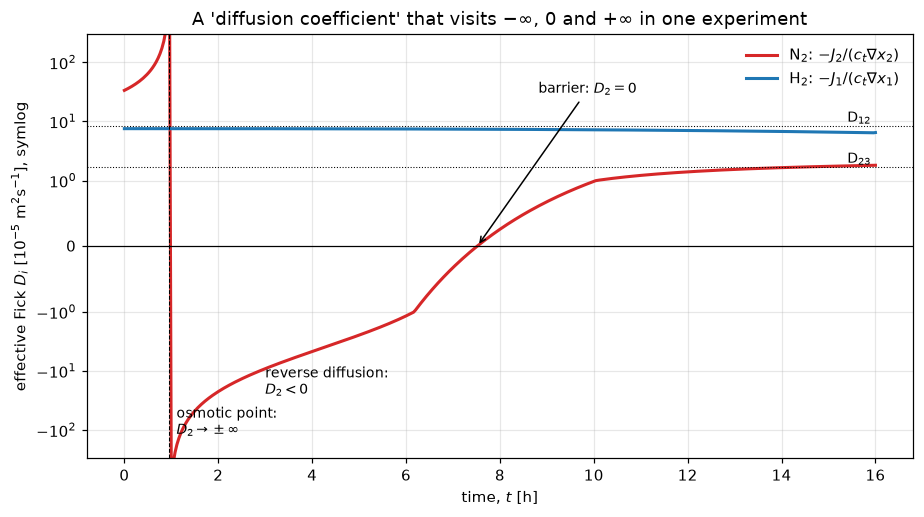

D2_eff range over the run: -793.9e-5 ... 5494.6e-5 m2/s (and passes through both infinities)
D1_eff (H2) range        : 6.43e-5 ... 7.55e-5 m2/s - positive and finite throughout, straying at most 5.4%
   outside its own pair values (6.8-8.3e-5), so binary intuition survives for hydrogen


In [16]:
grad_n2 = (x2_ms[:, 1] - x1_ms[:, 1]) / length      # end-to-end gradient, 1/m
grad_h2 = (x2_ms[:, 0] - x1_ms[:, 0]) / length
d2_eff = -J_ms[:, 1] / (c_t * grad_n2)
d1_eff = -J_ms[:, 0] / (c_t * grad_h2)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(t_h, d2_eff * 1e5, color="tab:red", lw=2, label=r"N$_2$: $-J_2/(c_t\nabla x_2)$")
ax.plot(t_h, d1_eff * 1e5, color="tab:blue", lw=2, label=r"H$_2$: $-J_1/(c_t\nabla x_1)$")
for v, lab in [(d_ms[0, 1] * 1e5, r"$\mathrm{D}_{12}$"),
               (d_ms[1, 2] * 1e5, r"$\mathrm{D}_{23}$")]:
    ax.axhline(v, color="k", lw=0.7, ls=":")
    ax.text(15.4, v * 1.15, lab, fontsize=9)
ax.axhline(0, color="k", lw=0.8)
ax.set_yscale("symlog", linthresh=1.0)
ax.set_ylim(-300, 300)
ax.axvline(t_zero, color="k", lw=0.7, ls="--")
ax.text(t_zero + 0.15, -120, "osmotic point:\n$D_{2}\\to\\pm\\infty$", fontsize=9)
ax.text(3.0, -25, "reverse diffusion:\n$D_{2}<0$", fontsize=9)
ax.annotate("barrier: $D_{2}=0$", xy=(t_peak, 0), xytext=(t_peak + 1.3, 30),
            arrowprops=dict(arrowstyle="->", lw=1.0), fontsize=9)
ax.set_xlabel("time, $t$ [h]")
ax.set_ylabel(r"effective Fick $D_i$ [$10^{-5}$ m$^2$s$^{-1}$], symlog")
ax.set_title("A 'diffusion coefficient' that visits $-\\infty$, 0 and $+\\infty$ "
             "in one experiment")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

print(f"D2_eff range over the run: {d2_eff.min()*1e5:.1f}e-5 ... "
      f"{d2_eff.max()*1e5:.1f}e-5 m2/s (and passes through both infinities)")
band_lo, band_hi = d_ms[0, 2], d_ms[0, 1]          # H2 pair values, 6.8 - 8.33e-5
excursion = max(max(band_lo - d1_eff.min(), 0.0) / band_lo,
                max(d1_eff.max() - band_hi, 0.0) / band_hi)
print(f"D1_eff (H2) range        : {d1_eff.min()*1e5:.2f}e-5 ... "
      f"{d1_eff.max()*1e5:.2f}e-5 m2/s - positive and finite throughout, straying "
      f"at most {excursion:.1%}\n   outside its own pair values (6.8-8.3e-5), so "
      "binary intuition survives for hydrogen")

### The review's frozen-matrix flux estimate, tested

The review's initial-flux estimate froze $[D]$ at the equilibrium composition.
The full solve resolves $[D](x)$ along the capillary, where the composition
swings across the whole ternary range. Comparing the *flux ratio*
$J_2/J_1$ at $t=0$ (a convention-free number: the $\ell$ and $\Delta x$
bookkeeping cancels) for the review's own eq. (3) run measures what the
frozen-matrix shortcut costs:

In [17]:
# The review's highlighted run, its eq. (3). CAREFUL: the review's "bulb 1" is
# the N2 + CO2 charge, i.e. Duncan & Toor's (and this page's) bulb 2. The two
# ends are therefore named by CHARGE here, not by number. Only the steady
# capillary enters, so no bulb volume is used; and the reported ratio J2/J1 is
# invariant under swapping the two ends anyway.
x_n2co2 = np.array([V["dt_run", "x1_bulb1"], V["dt_run", "x2_bulb1"],
                    V["dt_run", "x3_bulb1"]])      # review's bulb 1
x_h2n2 = np.array([V["dt_run", "x1_bulb2"], V["dt_run", "x2_bulb2"],
                   V["dt_run", "x3_bulb2"]])       # review's bulb 2

x_init = np.linspace(0, 1, n_z)[:, None] * (x_h2n2[:n_i] - x_n2co2[:n_i]) + x_n2co2[:n_i]
x_ss, ok = solve_capillary(flux_ms, x_init, x_n2co2, x_h2n2)
j_ss = flux_ms(x_ss, x_n2co2, x_h2n2).mean(axis=0)
ratio_full = float(j_ss[1] / j_ss[0])

print(f"steady capillary solve converged: {ok}")
print(f"J2/J1 at t=0, review's frozen-[D] estimate : {ratio_print:+.3f}")
print(f"J2/J1 at t=0, full composition-dependent   : {ratio_full:+.3f}")
est_vs_full = abs(ratio_full - ratio_print) / abs(ratio_full)
print(f"frozen-matrix shortcut error in the ratio  : {est_vs_full:.1%}")
print("\nWith the N2 driving force essentially zero, both give a nitrogen flux "
      "about half the\nhydrogen flux and opposite in sign - osmotic diffusion. "
      f"The {est_vs_full:.1%} shift is the\ncomposition dependence of [D] along "
      "the capillary, which the review's estimate\ndeliberately ignores and pymrm "
      "resolves.")

steady capillary solve converged: True
J2/J1 at t=0, review's frozen-[D] estimate : -0.499
J2/J1 at t=0, full composition-dependent   : -0.468
frozen-matrix shortcut error in the ratio  : 6.7%

With the N2 driving force essentially zero, both give a nitrogen flux about half the
hydrogen flux and opposite in sign - osmotic diffusion. The 6.7% shift is the
composition dependence of [D] along the capillary, which the review's estimate
deliberately ignores and pymrm resolves.


## Validation

Eight checks: two against the paper's printed numbers, five internal
(3, 3b, 4, 5, 6), and one against the (cross-page) measurements. The
deviation convention on this page is **model − measured**, reported in mole %
(absolute mole-fraction difference × 100) for compositions and relative for
matrix elements.

Check 3 is the one that carries weight on the implementation: it compares
$[B]$-based results against the raw friction system over the whole ternary
composition triangle and over the whole transient, with no code in common.
Check 3b is deliberately labelled for what it is — an algebraic identity
between two ways of inverting the same $2\times2$ matrix, which would still
agree if that matrix were wrong.

In [18]:
# 1. Worked example 1: recomputed [D] vs the printed matrix (rounding-limited).
print(f"1. ideal-gas [D] vs printed, max element dev   : {ex1_d_maxdev:.2%}")

# 2. Worked example 2: [D] = [B]^-1 [Gamma] across the printed matrices.
print(f"2. non-ideal identity [B]^-1[Gamma] = [D]      : {ex2_identity_maxdev:.2%} max")

# 3. INDEPENDENT implementation: the raw friction system vs everything built
#    on [B]. Three probes - the matrix itself over the composition triangle,
#    the whole transient, and the friction balance the solve never used.
rng = np.random.default_rng(20260731)
x_probe = rng.dirichlet(np.ones(n_c), size=200)[:, :n_i]     # fixed seed
d_b_route = fick_matrix(x_probe)
d_friction = fick_matrix_from_friction(x_probe)
fick_indep_maxdev = float(np.max(np.abs(d_b_route - d_friction)
                                 / np.abs(d_friction)))
g0 = grad_of(x_ss, x_n2co2, x_h2n2); xf0 = face_of(x_ss, x_n2co2, x_h2n2)
j_full = friction_solve(full_x(xf0), g0)
unused_balance = float(friction_residual(full_x(xf0), g0, j_full))
print(f"3. independent friction route (no [B] anywhere):")
print(f"     [D] over 200 random ternary compositions   : {fick_indep_maxdev:.1e} rel")
print(f"     whole two-bulb transient                   : {ms_indep_equiv:.1e} mole fraction")
print(f"     the friction balance NOT used in the solve : {unused_balance:.1e} (must vanish)")

# 3b. Algebraic identity, not an independent check: flux_ms and flux_fick both
#     call build_b, so this confirms the closed-form 2x2 inverse only.
print(f"3b. algebraic identity, [B]-solve vs adjugate/det: {ms_fick_equiv:.2e}")

# 4. Conservation: closed cell, so every species' total moles is constant.
tot0 = vol_1 * x1_0 + vol_2 * x2_0
tot1 = vol_1 * x1_ms[-1] + vol_2 * x2_ms[-1]
mole_err = float(np.abs(tot1 - tot0).max() / tot0.sum())
print(f"4. species mole-balance error (closed cell)    : {mole_err:.2e}")

# 5. Quasi-steady + time-step independence.
j_chk = flux_ms(x_ss, x_n2co2, x_h2n2)
flux_spread = float(np.abs(j_chk - j_chk.mean(axis=0)).max() / np.abs(j_chk).max())
t_f, x1_f, _, _, _ = simulate(flux_ms, x1_0, x2_0, n_steps=800)
dt_err = float(np.abs(np.interp(t_h, t_f, x1_f[:, 1]) - x1_ms[:, 1]).max())
print(f"5. flux non-uniformity along capillary         : {flux_spread:.2e}"
      f";  max N2 shift on halving dt: {dt_err:.2e}")

# 6. Elimination invariance (from the permutation runs above).
print(f"6. elimination invariance of Maxwell-Stefan    : {ms_elim_spread:.1e} "
      f"mole fraction over the three orderings\n"
      f"   same for the Wilke scalar closure           : "
      f"{(max(wk_means)-min(wk_means))/100:.1e} - i.e. the scalar answer is a "
      f"bookkeeping choice")

# 7. Against the measurements, both closures, all digitised points.
dev_ms = dev_vs_exp(x1_ms, x2_ms)
dev_wk = dev_vs_exp(x1_wk, x2_wk)
print(f"7. vs experiment, mean |model - measured|      : "
      f"Maxwell-Stefan {dev_ms.mean()*100:.2f} mole %, Wilke (CO2 eliminated) "
      f"{dev_wk.mean()*100:.2f} mole %")
n2_ms = np.abs(np.interp(exp_n2.index, t_h, dx_ms) - dx_exp)
n2_wk = np.abs(np.interp(exp_n2.index, t_h, dx_wk) - dx_exp)
print(f"   N2 bulb-difference error                    : "
      f"Maxwell-Stefan {n2_ms.mean()*100:.2f} mole %, Wilke {n2_wk.mean()*100:.2f} mole %")
print("   This is the SAME computation A4.9 published (same solver, grid, step "
      "count and\n   dataset), so its 0.59 mole % is necessarily reproduced, not "
      "independently\n   corroborated - it confirms the port is faithful, nothing "
      "more. For scale: the\n   review's own predictions deviate 0.45 mole %, the "
      "experimental error is\n   2.6 mole %, and A4.9's digitisation floor is "
      "+/-0.005 mole fraction = 0.5 mole %,\n   so the Maxwell-Stefan agreement is "
      "resolution-limited and should not be read as\n   tighter than that.")

# Structural defect of the scalar closure, for the record: applied to ALL
# THREE species it gives fluxes that do not sum to zero, violating the isobaric
# closed-cell constraint. Evaluated on the Maxwell-Stefan steady profile of the
# eq. (3) run, with grad x3 = -(grad x1 + grad x2).
grad_all = np.column_stack([g0, -(g0[:, 0] + g0[:, 1])])
jw = -c_t * wilke_d(xf0, which=range(n_c)) * grad_all
wilke_closure = float(np.abs(jw.sum(axis=1)).max() / np.abs(jw).max())
print(f"\n   Wilke closure defect: |sum_i J_i| reaches {wilke_closure:.1%} of the "
      "largest flux - the scalar\n   law cannot even satisfy the equimolar "
      "constraint, which is why one species has to\n   be demoted to a dependent "
      "one in the first place.")

report_agreement("A4.2", {
    "ex1_fick_matrix_maxdev": ex1_d_maxdev,
    "ex2_identity_maxdev": ex2_identity_maxdev,
    "b12_backsolve_magnitude_dev": float(b12_magdev),
    "fick_matrix_independent_maxdev": fick_indep_maxdev,
    "ms_independent_equivalence": ms_indep_equiv,
    "unused_friction_balance": unused_balance,
    "ms_fick_algebraic_identity": ms_fick_equiv,
    "mole_balance_error": mole_err,
    "flux_nonuniformity": flux_spread,
    "timestep_sensitivity": dt_err,
    "ms_elimination_spread": ms_elim_spread,
    "mean_abs_dev_ms": float(dev_ms.mean()),
    "mean_abs_dev_wilke": float(dev_wk.mean()),
    "mean_abs_dev_wilke_elim_h2": perm_res[("H2", "Wilke")][0],
    "mean_abs_dev_wilke_elim_n2": perm_res[("N2", "Wilke")][0],
    "n2_diff_err_ms": float(n2_ms.mean()),
    "n2_diff_err_wilke": float(n2_wk.mean()),
    "n2_diff_err_wilke_elim_h2": perm_res[("H2", "Wilke")][1],
    "n2_diff_err_wilke_elim_n2": perm_res[("N2", "Wilke")][1],
    "wilke_closure_defect": wilke_closure,
    "frozen_matrix_ratio_error": est_vs_full,
})

1. ideal-gas [D] vs printed, max element dev   : 1.03%
2. non-ideal identity [B]^-1[Gamma] = [D]      : 1.65% max
3. independent friction route (no [B] anywhere):
     [D] over 200 random ternary compositions   : 3.1e-12 rel
     whole two-bulb transient                   : 7.8e-16 mole fraction
     the friction balance NOT used in the solve : 4.5e-16 (must vanish)
3b. algebraic identity, [B]-solve vs adjugate/det: 8.88e-16
4. species mole-balance error (closed cell)    : 2.16e-16


5. flux non-uniformity along capillary         : 1.94e-14;  max N2 shift on halving dt: 1.48e-04
6. elimination invariance of Maxwell-Stefan    : 3.9e-16 mole fraction over the three orderings
   same for the Wilke scalar closure           : 2.9e-02 - i.e. the scalar answer is a bookkeeping choice
7. vs experiment, mean |model - measured|      : Maxwell-Stefan 0.59 mole %, Wilke (CO2 eliminated) 3.14 mole %
   N2 bulb-difference error                    : Maxwell-Stefan 1.38 mole %, Wilke 9.07 mole %
   This is the SAME computation A4.9 published (same solver, grid, step count and
   dataset), so its 0.59 mole % is necessarily reproduced, not independently
   corroborated - it confirms the port is faithful, nothing more. For scale: the
   review's own predictions deviate 0.45 mole %, the experimental error is
   2.6 mole %, and A4.9's digitisation floor is +/-0.005 mole fraction = 0.5 mole %,
   so the Maxwell-Stefan agreement is resolution-limited and should not be read as
   tighter 

{'page': 'A4.2',
 'metrics': {'ex1_fick_matrix_maxdev': 0.0102806977012818,
  'ex2_identity_maxdev': 0.016518108497430104,
  'b12_backsolve_magnitude_dev': 0.0021367521367520095,
  'fick_matrix_independent_maxdev': 3.0672216010632692e-12,
  'ms_independent_equivalence': 7.771561172376096e-16,
  'unused_friction_balance': 4.489381717764758e-16,
  'ms_fick_algebraic_identity': 8.881784197001252e-16,
  'mole_balance_error': 2.1632816939198067e-16,
  'flux_nonuniformity': 1.9354963477142276e-14,
  'timestep_sensitivity': 0.00014848833019553975,
  'ms_elimination_spread': 3.885780586188048e-16,
  'mean_abs_dev_ms': 0.0058826829695680805,
  'mean_abs_dev_wilke': 0.031385046561790676,
  'mean_abs_dev_wilke_elim_h2': 0.04307273703930611,
  'mean_abs_dev_wilke_elim_n2': 0.014425589246090659,
  'n2_diff_err_ms': 0.013821036277773225,
  'n2_diff_err_wilke': 0.09072152578046487,
  'n2_diff_err_wilke_elim_h2': 0.09028344228275977,
  'n2_diff_err_wilke_elim_n2': 0.03392986361484397,
  'wilke_closure

## What pymrm adds

**Honestly: the transport solver is the `A4.9` page's, reused** — same grid,
operators and Newton march, and the mean deviation against the measurements is
therefore the same number A4.9 already publishes, by construction. What this
page adds sits at the formulation level:

- **The equivalence checked by a route that could have failed.** Eq. (27) says
  Maxwell–Stefan and the generalized Fick matrix are the same physics. Coding
  $[B]$ twice — a linear solve and its closed-form inverse — cannot show that,
  because a mistake in $[B]$ survives both. So the page also solves the raw
  friction balances with the $\sum_k J_k = 0$ bootstrap, eliminating nothing
  and never forming $[B]$: it reproduces $[D](x)$ over the whole composition
  triangle and the entire two-bulb transient to machine precision. The
  often-repeated "Maxwell–Stefan vs Fick" contest is really Maxwell–Stefan vs
  the *scalar* shortcut.
- **Why the scalar shortcut fails, not just by how much.** That it *does* fail
  on this experiment is `A4.9`'s published result (9.1 against 1.4 mole % on
  the nitrogen signal); this page reaches 9.07 against 1.38 by a completely
  different route — a full local-composition Wilke solve rather than a
  frozen-$[D]$ analytic relaxation — which is a cross-check on both. The new
  content is the structure of the failure: (i) a positive scalar diffusivity
  moves a species strictly down its own gradient, so the bulb difference of
  any species *carrying* the scalar law decays monotonically and no barrier is
  possible; (ii) applied to all three species at once the scalar fluxes
  violate the closed-cell constraint $\sum_i J_i = 0$ by **105%** of the
  largest flux, which is why one species always has to be demoted; and
  (iii) the scalar answer *depends on that demotion* — 1.44 to 4.31 mole %
  mean deviation depending only on which species is eliminated — while
  Maxwell–Stefan is invariant to $10^{-16}$. A model whose prediction moves by
  a factor of three under a relabelling is not a transport model.
- **The effective-diffusivity trace.** The review argues in a sketch (its
  Fig. 4) that $D_{2}$ must visit $\pm\infty$, negative values and zero;
  backing $-J_2/(c_t\nabla x_2)$ out of the pymrm solution turns that sketch
  into a computed curve with the three regimes timestamped.
- **A typo in the source settled from its own numbers, non-circularly.** The
  printed $B_{12} = -0.036\times10^9$ of the non-ideal example is contradicted
  by a back-solve that never uses it: the other three printed elements of
  $[B]$ fix the authors' unrounded diffusivities (3.375/2.507/1.661e-9), and
  eq. (26) then returns $B_{12} = +0.0359\times10^9$ — the printed magnitude,
  the opposite sign. The review's *other* worked example prints a positive
  $B_{12}$ under the same diffusivity ordering, the corrected sign closes the
  printed triple to ≤1.7%, and the rival "$B_{21}$ is the typo" hypothesis
  fails at 302%.
- **The frozen-matrix estimate priced.** The review's constant-$[D]$
  initial-flux estimate is good to ~7% in the flux ratio here; pymrm resolves
  the composition dependence along the capillary that the estimate discards.

What the page does **not** do: no new experimental data (the measurements are
`A4.9`'s digitised dataset, used cross-page), no non-ideal *transport* solve
(the $[\Gamma]$ example is verified as printed matrix algebra only), and
nothing beyond the review's bulk-fluid sections — the dusty-gas and surface
chapters belong to `A4.3` and `H1.9`.

## Reuse

**To adapt this page to your system**, change in order:

| Change | Where |
|---|---|
| Different species or more of them | `SPECIES`, `d_ms`, `n_c`; `build_b`/`fick_matrix` generalize as written except the 2×2 closed-form inverse — use `np.linalg.inv` for $n>3$. `friction_solve` generalizes unchanged |
| A different species order | free for Maxwell–Stefan, *not* for the scalar closure — `run_ordering` and the permutation table above show the cost. If you use `flux_wilke`, say which species carries the scalar law |
| Non-ideal mixture | multiply the solved $[B]^{-1}$ by $[\Gamma](x)$ in `flux_ms` (the `nonideal` example's matrices show the pattern) |
| Different geometry | `length`, `vol_1`, `vol_2`, `LA_EFF`, and `nu` in `construct_div` |
| Porous medium | add Knudsen terms to $[B]$ — the dusty gas model, page `A4.3` |
| A quick screening decision | evaluate `fick_matrix` at your feed composition: if the off-diagonal elements rival the diagonal (here $|D_{21}/D_{22}| \approx 1.8$), a scalar effective diffusivity will misbehave |

The three `flux_*` closures against one skeleton are the reusable pattern:
any `struct:S9` page can swap constitutive models this way and regression-test
their agreement.

**Related pages:** `A4.9` Duncan–Toor ternary diffusion (the experiment, and
the source of the dataset used here) · `A4.3` dusty gas model · `A4.8` Stefan
tube · `B1.11` multicomponent pellet · `H1.9` zeolite membrane permeation.

## References

Krishna, R. and Wesselingh, J. A. (1997). *The Maxwell–Stefan approach to
mass transfer.* Chemical Engineering Science **52**(6), 861–911.
[doi:10.1016/S0009-2509(96)00458-7](https://doi.org/10.1016/S0009-2509(96)00458-7)

Duncan, J. B. and Toor, H. L. (1962). *An experimental study of three
component gas diffusion.* AIChE Journal **8**(1), 38–41.
[doi:10.1002/aic.690080112](https://doi.org/10.1002/aic.690080112)

Toor, H. L. (1957). *Diffusion in three-component gas mixtures.* AIChE
Journal **3**(2), 198–207.

Wilke, C. R. (1950). *Diffusional properties of multicomponent gases.*
Chemical Engineering Progress **46**, 95–104.

Taylor, R. and Krishna, R. (1993). *Multicomponent Mass Transfer.* Wiley.